# LSTM modificadas para usar invariantes temporales:

__Los siguientes scripts comprueban si se va a usar la GPU en el entrenamiento, en caso de tener problemas, recomendamos usar un docker de nvidia para hacer el entrenamiento ya que puede haber problemas con la version de cudnn que instala uv__

In [1]:
import torch

# Comprobar si CUDA está disponible
print(torch.cuda.is_available())

# Ver el nombre de la GPU detectada
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5070 Laptop GPU


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


In [3]:
import torch
import time

def test_cuda():
    print(f"Versión de PyTorch: {torch.__version__}")
    
    if not torch.cuda.is_available():
        print("CUDA no está disponible. Revisa tus drivers o la versión de PyTorch.")
        return

    # Información de la GPU
    device = torch.device("cuda")
    print(f"CUDA detectado: {torch.cuda.get_device_name(0)}")
    print(f"Versión de CUDA de PyTorch: {torch.version.cuda}")

    # Test de estrés rápido: Multiplicación de matrices
    try:
        # Creamos dos matrices de 5000x5000 en la GPU
        x = torch.randn(5000, 5000).to(device)
        y = torch.randn(5000, 5000).to(device)
        
        start = time.time()
        # Operación en GPU
        resultado = torch.matmul(x, y)
        # Sincronizamos para medir el tiempo real
        torch.cuda.synchronize() 
        end = time.time()

        print(f"Test completado: Multiplicación 5000x5000 en {end - start:.4f} segundos.")
        print("La GPU está procesando tensores correctamente.")

    except Exception as e:
        print(f"Error durante el test: {e}")

if __name__ == "__main__":
    test_cuda()

Versión de PyTorch: 2.10.0+cu128
CUDA detectado: NVIDIA GeForce RTX 5070 Laptop GPU
Versión de CUDA de PyTorch: 12.8
Test completado: Multiplicación 5000x5000 en 0.0876 segundos.
La GPU está procesando tensores correctamente.


## Librerias necesarias

In [4]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient


from pyspark.ml.feature import StringIndexer, OneHotEncoder,VectorAssembler, StandardScaler
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.sql.window import Window
import math
from torch.utils.data import IterableDataset, DataLoader
import s3fs
import pyarrow.parquet as pq

from clearml import Task
from tqdm.auto import tqdm

from setup import setenv
setenv()

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Explicación de la idea:

Como podemos ver en los otros notebooks, existen modelos muy potentes que permiten obtener resultados muy buenos, el problema es que tantro el TiDE como el TFT requieren una capacidad de computo muy grande. Como primera aproximación utilizaremos una pequeña modificación de una LSTM, lo cual es mucho más simple y rápido:

- Por un lado tenemos el Id del localizardor, con geopandas podemos sacar las coordenadas del centroide. Se puede ver que los barrios de una zona demandada también son demandados, por tanto usar la latitud y longitud del centroide es una medida numérica que nos puede evitar el uso de embeddings.

- El otro invariante que tenemos es el Id del servicio, al ser solo 4 haremos un one-hot-encoding y ya.

- Al resto de datos les debemos hacer un group-normalizer para que esten en la misma escalada y pasar estos datos a la LSTM común.

- Una vez tenemos los tres outputs, se pasan a una capa densa la cual predecirá la demanda normalizada, la cual simplemente desnormalizaremos para calcular el Loss.

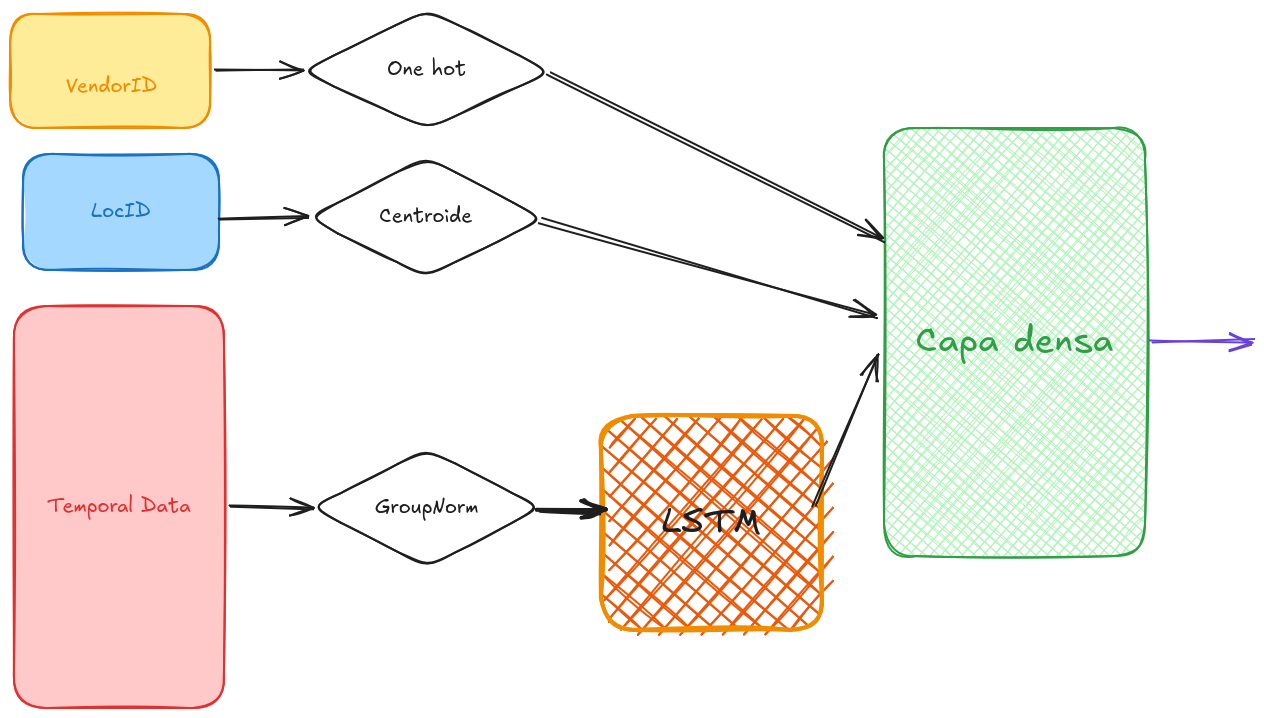

## Descarga de los datos

In [5]:
spark = MinioSparkClient(
    endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
    access_key=os.getenv("MINIO_ACCESS_KEY"),
    secret_key=os.getenv("MINIO_SECRET_KEY"),
    bucket_name="pd2",
    base_dir="cityenjoyer",
    memory = 16,
    heapsize = 8,
    num_part = 2000,
    verbose=True
)
spark.connect()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/16 09:45:09 WARN Utils: Your hostname, danpanto-OMEN-Gaming-Laptop-16-ap0xxx, resolves to a loopback address: 127.0.1.1; using 10.8.101.56 instead (on interface wlo1)
26/03/16 09:45:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/03/16 09:45:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [ ]:
df = spark.read_parquet("21-25_clipped.parquet")
df.show()

descargamos también los centroides

In [ ]:
centroids = spark.read_parquet("map_centroids.parquet")
centroids.show()

+----------+------------------+------------------+
|locationid|          Latitude|         Longitude|
+----------+------------------+------------------+
|         1|40.691829681396484|-74.17400360107422|
|         2| 40.61674499511719|  -73.831298828125|
|         3| 40.86447525024414|-73.84741973876953|
|         4|40.723751068115234|-73.97696685791016|
|         5| 40.55265808105469|-74.18848419189453|
|         6| 40.60032272338867|-74.07176971435547|
|         7| 40.76149368286133|-73.91969299316406|
|         8| 40.77855682373047|-73.92308807373047|
|         9|40.751033782958984|-73.78794860839844|
|        10|   40.678955078125|-73.79098510742188|
|        11|40.604270935058594|-74.00748443603516|
|        12|40.702945709228516|-74.01556396484375|
|        13|40.712039947509766|-74.01608276367188|
|        14| 40.62483596801758|-74.02989196777344|
|        15| 40.78333282470703|-73.78597259521484|
|        16| 40.76273727416992|-73.77342224121094|
|        17| 40.69150924682617|

## Transformaciones necesarias:

- Primero es necesario hacer el onehotencoding de la empresa
- Concatenar las coordenadas geográficas.
- Añadir el seno y el coseno de la hora y el dia
- Hacer el groupnormalizer

Primero hagamos la agregación temporal

In [8]:
df_aggregated = df.groupBy(
    "VendorID", 
    "PULocationID", 
    F.window("pickup_datetime", "1 hour").alias("window")
).agg(
    F.count("*").alias("demand"),
    F.avg("trip_distance").alias("avg_distance"),
    F.avg("total_amount").alias("avg_amount")
).select(
    "VendorID", 
    "PULocationID", 
    F.col("window.start").alias("timestamp"),
    "demand", "avg_distance", "avg_amount"
)

df_aggregated.show()

+--------+------------+-------------------+------+------------------+------------------+
|VendorID|PULocationID|          timestamp|demand|      avg_distance|        avg_amount|
+--------+------------+-------------------+------+------------------+------------------+
|       2|         141|2022-08-01 00:00:00|    40|            8444.9|           2719.15|
|       3|          68|2022-08-01 02:00:00|    19| 7825.789473684211|2448.5263157894738|
|       3|         233|2022-08-01 09:00:00|    64|        4918.90625|       1960.890625|
|       2|          97|2022-08-01 13:00:00|    80|         6605.0875|         2327.4875|
|       2|         119|2022-08-01 14:00:00|    57|  8308.78947368421| 2587.245614035088|
|       2|          51|2022-08-01 16:00:00|    69| 7704.260869565217|2221.3623188405795|
|       2|          44|2022-08-01 17:00:00|     4|            3447.5|            1144.0|
|       2|          81|2022-08-01 20:00:00|    38|7325.3421052631575| 1833.921052631579|
|       3|         16

Ahora añadamos los centroides

In [9]:
df_with_geo = df_aggregated.join(
    centroids, 
    df_aggregated.PULocationID == centroids.locationid, 
    "left"
).drop("locationid")
df_with_geo.show()

+--------+------------+-------------------+------+------------------+------------------+------------------+------------------+
|VendorID|PULocationID|          timestamp|demand|      avg_distance|        avg_amount|          Latitude|         Longitude|
+--------+------------+-------------------+------+------------------+------------------+------------------+------------------+
|       2|         141|2022-08-01 00:00:00|    40|            8444.9|           2719.15| 40.76694869995117|-73.95963287353516|
|       3|          68|2022-08-01 02:00:00|    19| 7825.789473684211|2448.5263157894738| 40.74842834472656|-73.99991607666016|
|       3|         233|2022-08-01 09:00:00|    64|        4918.90625|       1960.890625| 40.74991226196289|-73.97044372558594|
|       2|          97|2022-08-01 13:00:00|    80|         6605.0875|         2327.4875| 40.69078826904297|-73.97488403320312|
|       2|         119|2022-08-01 14:00:00|    57|  8308.78947368421| 2587.245614035088|40.837825775146484|-73.

Ahora creemos las columnas que sean los datos temporales

In [10]:
PI2 = 2 * math.pi
df_transformed = df_with_geo.withColumn("hour", F.hour("timestamp")) \
    .withColumn("dow", F.dayofweek("timestamp")) \
    .withColumn("hour_sin", F.sin(F.col("hour") * (PI2 / 24))) \
    .withColumn("hour_cos", F.cos(F.col("hour") * (PI2 / 24))) \
    .withColumn("dow_sin", F.sin(F.col("dow") * (PI2 / 7))) \
    .withColumn("dow_cos", F.cos(F.col("dow") * (PI2 / 7))).dropna()
df_transformed.show()

+--------+------------+-------------------+------+------------------+------------------+------------------+------------------+----+---+--------------------+--------------------+-------------------+--------------------+
|VendorID|PULocationID|          timestamp|demand|      avg_distance|        avg_amount|          Latitude|         Longitude|hour|dow|            hour_sin|            hour_cos|            dow_sin|             dow_cos|
+--------+------------+-------------------+------+------------------+------------------+------------------+------------------+----+---+--------------------+--------------------+-------------------+--------------------+
|       2|         141|2022-08-01 00:00:00|    40|            8444.9|           2719.15| 40.76694869995117|-73.95963287353516|   0|  2|                 0.0|                 1.0| 0.9749279121818236|-0.22252093395631434|
|       3|          68|2022-08-01 02:00:00|    19| 7825.789473684211|2448.5263157894738| 40.74842834472656|-73.9999160766601

Guardamos este dataset como raw:

In [12]:
spark.write_parquet(df_transformed, "data_processed.parquet")

In [13]:
df_preprocessed = spark.read_parquet("data_processed.parquet")

In [14]:
df_preprocessed.show()

+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|        avg_amount|          Latitude|         Longitude|hour|dow|            hour_sin|            hour_cos|             dow_sin|             dow_cos|
+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|       0|           1|2021-01-03 17:00:00|     1|        48.0|            2080.0|40.691829681396484|-74.17400360107422|  17|  1| -0.9659258262890681| -0.2588190451025215|  0.7818314824680298|  0.6234898018587336|
|       0|           1|2021-01-26 13:00:00|     1|         0.0|            1896.0|40.691829681396484|-74.17400360107422|  13|  3|-0.258819045102

In [3]:
if "df_transformed" in locals():
    df_preprocessed = df_transformed
else:
    df_preprocessed = spark.read_parquet("data_processed.parquet")

df_preprocessed.show()

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|        avg_amount|          Latitude|         Longitude|hour|dow|            hour_sin|            hour_cos|             dow_sin|             dow_cos|
+--------+------------+-------------------+------+------------+------------------+------------------+------------------+----+---+--------------------+--------------------+--------------------+--------------------+
|       0|           1|2021-01-03 17:00:00|     1|        48.0|            2080.0|40.691829681396484|-74.17400360107422|  17|  1| -0.9659258262890681| -0.2588190451025215|  0.7818314824680298|  0.6234898018587336|
|       0|           1|2021-01-26 13:00:00|     1|         0.0|            1896.0|40.691829681396484|-74.17400360107422|  13|  3|-0.258819045102

Ahora queda crear un pipeline para usar los encoders que ofrece spark y crear el DF final que usaremos en nuestro modelo

In [4]:
window_size = 5

# ---------------------------------------------------------
indexer = StringIndexer(inputCol="VendorID", outputCol="VendorIndex")
indexed_df = indexer.fit(df_preprocessed).transform(df_preprocessed)

encoder = OneHotEncoder(inputCol="VendorIndex", outputCol="VendorOneHot", dropLast=False)
df_encoded = encoder.fit(indexed_df).transform(indexed_df)

# Convertimos el onehot en un array
df_encoded = df_encoded.withColumn("vendor_array", vector_to_array("VendorOneHot"))


# Creamos dos ventanas
calc_window = Window.partitionBy("VendorID", "PULocationID") \
                    .orderBy("timestamp") \
                    .rowsBetween(Window.unboundedPreceding, 0)

lead_window = Window.partitionBy("VendorID", "PULocationID") \
                    .orderBy("timestamp")

#Normalizamos sin tener en cuenta el futuro
continuous_vars = ["demand", "avg_distance", "avg_amount"]
for col_name in continuous_vars:
    avg_col = F.avg(col_name).over(calc_window)
    std_col = F.stddev(col_name).over(calc_window)
    
    df_encoded = df_encoded.withColumn(f"{col_name}_mu", avg_col)
    df_encoded = df_encoded.withColumn(f"{col_name}_sigma", 
        F.when(F.coalesce(std_col, F.lit(0)) == 0, F.lit(1.0)).otherwise(std_col)
    )
    
    df_encoded = df_encoded.withColumn(
        f"norm_{col_name}", 
        (F.col(col_name) - F.col(f"{col_name}_mu")) / F.col(f"{col_name}_sigma")
    )

df_encoded = df_encoded.withColumn("label", F.lead("norm_demand", 1).over(lead_window))

# Lsecuencia que va al LSTM
temporal_cols = ["norm_demand", "norm_avg_distance", "norm_avg_amount", 
                 "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

df_encoded = df_encoded.withColumn("feat_step", F.array(*temporal_cols))


seq_window = Window.partitionBy("VendorID", "PULocationID") \
                   .orderBy("timestamp") \
                   .rowsBetween(-(window_size - 1), 0)

df_final = df_encoded.withColumn("temporal_sequence", F.collect_list("feat_step").over(seq_window))


dataset_df = df_final.filter(F.size("temporal_sequence") == window_size) \
                     .dropna(subset=["label"])

final_dataset = dataset_df.select(
    "timestamp",
    "VendorID",
    "PULocationID",
    "vendor_array",
    F.array("Latitude", "Longitude").alias("centroid"),
    "temporal_sequence",
    "label",
    "demand_mu",
    "demand_sigma"
).orderBy("timestamp")

Subamos este dataframe a Minio en caso de necesitarlo para otras pruebas

In [5]:
spark.write_parquet(final_dataset, "lstm_data.parquet")

Descargar datos si no has ejecutado el pipeline anterior

In [6]:
if "final_dataset" in locals():
    df_lstm = final_dataset
else:
    df_lstm = spark.read_parquet("lstm_data.parquet")

df_lstm.show()

SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.


+-------------------+--------+------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+
|          timestamp|VendorID|PULocationID|        vendor_array|            centroid|   temporal_sequence|               label|         demand_mu|      demand_sigma|
+-------------------+--------+------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+
|2024-03-17 10:00:00|       0|          48|[0.0, 0.0, 1.0, 0.0]|[40.7622528076171...|[[-0.814357195639...|   1.231614432566383|117.73522298883277| 65.97936645805078|
|2024-03-17 10:00:00|       0|          65|[0.0, 0.0, 1.0, 0.0]|[40.6953392028808...|[[-1.050836256661...|  -1.050829617732001|3.7682501341921633| 2.634223293814561|
|2024-03-17 10:00:00|       0|          90|[0.0, 0.0, 1.0, 0.0]|[40.7422790527343...|[[-1.153961015975...|  0.7066514263587458| 70.85513702291436|  44.0726923871811|
|202

In [9]:
df_lstm.count()

28419022

Vamos a comprobar que no hay data leak

In [11]:
window_size=5

def audit_data_leakage(df_final, window_size):
    print("Iniciando Test Anti-Leakage...")
    
    # 1. Verificación de Timestamps: El tiempo del Label debe ser > tiempo del último step
    # Para esto, necesitamos recuperar el timestamp del 'lead'
    check_window = Window.partitionBy("VendorID", "PULocationID").orderBy("timestamp")
    df_audit = df_final.withColumn("label_timestamp", F.lead("timestamp", 1).over(check_window))
    
    # Filtrar donde el label (futuro) sea menor o igual al presente
    time_errors = df_audit.filter(F.col("label_timestamp") <= F.col("timestamp")).count()
    
    # 2. Verificación de Contenido: ¿Está el valor del label dentro de la secuencia de entrada?
    # El label es 'norm_demand' en t+1. El 'norm_demand' en t es el último elemento de la secuencia.
    # Comprobamos que label != norm_demand_t (a menos que sea coincidencia estadística)
    # Pero lo más importante: comprobar que el label NO sea igual a ningún valor pasado de forma sistemática.
    
    sample_data = df_final.select("temporal_sequence", "label").limit(100).collect()
    
    exact_matches = 0
    for row in sample_data:
        sequence = row['temporal_sequence']
        label = row['label']
        # El primer valor de cada step es 'norm_demand'
        demands_in_sequence = [step[0] for step in sequence]
        
        # Si el label es EXACTAMENTE igual al último valor de la secuencia siempre, 
        # podrías estar prediciendo t con t.
        if float(label) == float(demands_in_sequence[-1]):
            exact_matches += 1

    # --- RESULTADOS ---
    print("-" * 40)
    if time_errors == 0:
        print("PASSED: La cronología es consistente. El futuro siempre va después del presente.")
    else:
        print(f"FAILED: Se encontraron {time_errors} filas donde el futuro ocurre antes que el presente.")

    if exact_matches < len(sample_data) * 0.1: # Es normal que coincidan a veces por azar
        print(f"PASSED: No hay correlación identitaria sistemática (Solo {exact_matches}% de coincidencia exacta).")
    else:
        print(f"WARNING: El label coincide con el último step el {exact_matches}% de las veces. Revisa si 'label' y 'norm_demand' están bien desplazados.")
    print("-" * 40)

# Ejecutar
audit_data_leakage(df_lstm, window_size)

Iniciando Test Anti-Leakage...


----------------------------------------
FAILED: Se encontraron 108222 filas donde el futuro ocurre antes que el presente.
PASSED: No hay correlación identitaria sistemática (Solo 0% de coincidencia exacta).
----------------------------------------


Parece que es solo coincidencia y no hay data leak 

Para guardarlo en local si fuese necesario

In [8]:
df_lstm.write.format("parquet") \
    .option("compression", "snappy") \
    .save("../data/lstm_model.parquet")

## Creación del modelo

In [6]:
class TaxiDemandLSTM(nn.Module):
    def __init__(self, vendor_dim, window_size, feature_dim):
        super(TaxiDemandLSTM, self).__init__()
        
        # El one-hot de los servicios
        self.vendor_fc = nn.Linear(vendor_dim, 16)
        
        # los centroides
        self.centroid_fc = nn.Linear(2, 16)
        
        # Los datos temporales que van a pasar por la LSTM
        self.lstm = nn.LSTM(input_size=feature_dim, hidden_size=64, 
                            num_layers=1, batch_first=True)
        
        self.fc_final = nn.Sequential(
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, vendor, centroid, temporal_seq):
        v_out = torch.relu(self.vendor_fc(vendor))
        c_out = torch.relu(self.centroid_fc(centroid))
        
        # LSTM output: we take the last hidden state
        _, (h_n, _) = self.lstm(temporal_seq)
        lstm_out = h_n[-1] 
        
        # Concatenate paths
        combined = torch.cat((v_out, c_out, lstm_out), dim=1)
        return self.fc_final(combined)

In [7]:
class TaxiDataset(IterableDataset):
    def __init__(self, path, split="train", split_ratios=(0.8, 0.1, 0.1)):
        self.path = path
        # Get all fragments once to partition them
        full_ds = pq.ParquetDataset(self.path)
        fragments = sorted(full_ds.fragments, key=lambda f: f.path)
        
        num_frags = len(fragments)
        train_end = int(num_frags * split_ratios[0])
        val_end = train_end + int(num_frags * split_ratios[1])

        # Assign fragments based on the requested split
        if split == "train":
            self.fragments = fragments[:train_end]
        elif split == "val":
            self.fragments = fragments[train_end:val_end]
        else:  # test
            self.fragments = fragments[val_end:]

    def __iter__(self):
        for fragment in self.fragments:
            for batch in fragment.to_batches(batch_size=20480):
                df = batch.to_pydict()
                for i in range(len(batch)):
                    yield {
                        "vendor": torch.tensor(df["vendor_array"][i], dtype=torch.float32),
                        "centroid": torch.tensor(df["centroid"][i], dtype=torch.float32),
                        "temporal_seq": torch.tensor(df["temporal_sequence"][i], dtype=torch.float32),
                        "label": torch.tensor(df["label"][i], dtype=torch.float32)
                    }

# --- Initialization ---

data_path = "../data/lstm_model.parquet"

train_dataset = TaxiDataset(data_path, split="train")
val_dataset   = TaxiDataset(data_path, split="val")
test_dataset  = TaxiDataset(data_path, split="test")

train_loader = DataLoader(train_dataset, batch_size=512)
val_loader   = DataLoader(val_dataset, batch_size=512)
test_loader  = DataLoader(test_dataset, batch_size=512)

In [8]:
# Get one single batch from the loader
data_iter = iter(test_loader)
batch = next(data_iter)

print("--- Batch Shapes ---")
print(f"Vendor shape:   {batch['vendor'].shape}")       # Expected: [batch_size, 4]
print(f"Centroid shape: {batch['centroid'].shape}")     # Expected: [batch_size, 2]
print(f"Sequence shape: {batch['temporal_seq'].shape}") # Expected: [batch_size, seq_len, feat_dim]
print(f"Label shape:    {batch['label'].shape}")        # Expected: [batch_size]

# Check types
print(f"\nSequence Dtype: {batch['temporal_seq'].dtype}") # Expected: torch.float32

--- Batch Shapes ---
Vendor shape:   torch.Size([512, 4])
Centroid shape: torch.Size([512, 2])
Sequence shape: torch.Size([512, 5, 7])
Label shape:    torch.Size([512])

Sequence Dtype: torch.float32


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")


model = TaxiDemandLSTM(vendor_dim=4, window_size=5, feature_dim=7).to(device)


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

Training on: cuda


In [9]:
# 1. Setup Task with a proper name
Task.set_offline(offline_mode=True)
task = Task.init(project_name="Taxi_LSTM", task_name="Baseline_v1_3.13")
logger = task.get_logger()

def train_and_validate(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    train_history, val_history = [], []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        total_train_loss = 0
        train_batches = 0  
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", unit="batch")
        
        for batch in pbar:
            v, c, t, l = [batch[k].to(device) for k in ['vendor', 'centroid', 'temporal_seq', 'label']]
            
            optimizer.zero_grad()
            outputs = model(v, c, t)
            loss = criterion(outputs, l.unsqueeze(1)) # Ensure [Batch, 1] shape
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            train_batches += 1
            pbar.set_postfix({"train_loss": f"{loss.item():.4f}"})

        avg_train_loss = total_train_loss / train_batches
        train_history.append(avg_train_loss)

        # --- VALIDATE ---
        model.eval()
        total_val_loss = 0
        val_batches = 0
        
        # Validation Progress Bar
        vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", unit="batch", leave=False)
        
        with torch.no_grad():
            for batch in vbar:
                v, c, t, l = [batch[k].to(device) for k in ['vendor', 'centroid', 'temporal_seq', 'label']]
                val_outputs = model(v, c, t)
                v_loss = criterion(val_outputs, l.unsqueeze(1))
                
                total_val_loss += v_loss.item()
                val_batches += 1
                vbar.set_postfix({"val_loss": f"{v_loss.item():.4f}"})
        
        avg_val_loss = total_val_loss / val_batches
        val_history.append(avg_val_loss)

        # Log to ClearML
        logger.report_scalar("Loss", "Train", iteration=epoch, value=avg_train_loss)
        logger.report_scalar("Loss", "Val", iteration=epoch, value=avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # Save metadata with the model for easier recovery later
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss,
            }, "best_taxi_model.pth")
            print(f"--> Best model saved at Epoch {epoch+1} with Val Loss: {avg_val_loss:.6f}")

    return train_history, val_history

# Start Training
train_h, val_h = train_and_validate(model, train_loader, val_loader, optimizer, criterion, 10, device)

ClearML Task: created new task id=offline-6ac8ce075d47450e82153b6503e694be
ClearML running in offline mode, session stored in /home/danpanto/.clearml/cache/offline/offline-6ac8ce075d47450e82153b6503e694be


Epoch 1/10 [Train]: 11596batch [03:01, 84.04batch/s, train_loss=1.0082]

ClearML Task: created new task id=offline-6ac8ce075d47450e82153b6503e694be
ClearML running in offline mode, session stored in /home/danpanto/.clearml/cache/offline/offline-6ac8ce075d47450e82153b6503e694be
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


Epoch 1/10 [Train]: 44732batch [11:45, 63.40batch/s, train_loss=0.1760]


--> Best model saved at Epoch 1 with Val Loss: 0.504026


...

--> Best model saved at Epoch 8 with Val Loss: 0.486995


Epoch 9/10 [Train]: 44732batch [11:46, 63.30batch/s, train_loss=0.1634]


--> Best model saved at Epoch 9 with Val Loss: 0.486476


Epoch 10/10 [Train]: 44732batch [11:46, 63.28batch/s, train_loss=0.2304]
                                                                   

--> Best model saved at Epoch 10 with Val Loss: 0.485291


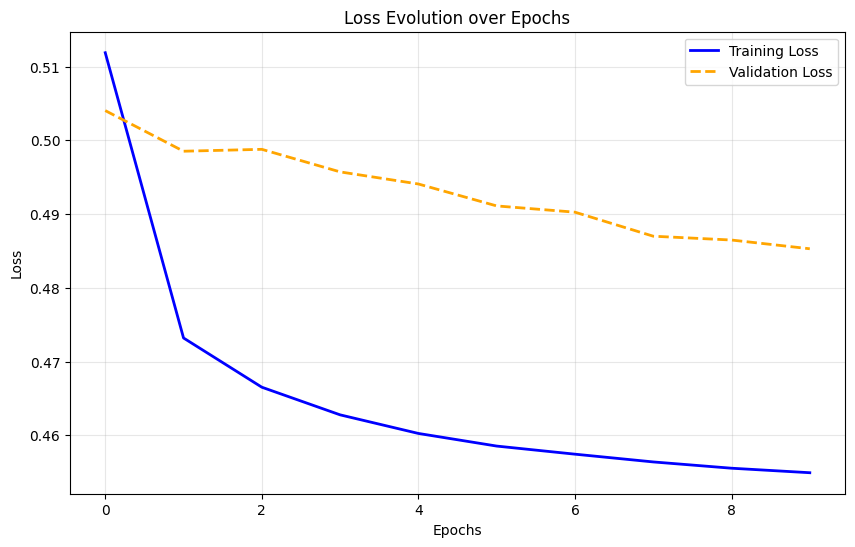

In [10]:
def plot_loss(train_loss, val_loss):
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Training Loss', color='blue', lw=2)
    plt.plot(val_loss, label='Validation Loss', color='orange', linestyle='--', lw=2)
    plt.title('Loss Evolution over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(train_h, val_h)

Una vez tenemos el modelo, comprobaremos su error y los residuos, si son suficientemente buenos, crearemos un pipeline para poder hacer inferencia con mayor comodidad y entrenar más modelos.

In [14]:
import torch
import numpy as np
from tqdm import tqdm

Task.set_offline(offline_mode=True)
task = Task.init(project_name="a", task_name="B")
logger = task.get_logger()

def evaluate_test_set(test_loader, model_path, criterion, device, logger):
    # 1. Load the best model weights
    print(f"Loading best model from: {model_path}")
    # Using standard torch load since we saved with torch.save earlier
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.eval()
    
    total_test_loss = 0
    test_batches = 0
    all_preds = []
    all_labels = []

    # 2. Run Inference
    pbar = tqdm(test_loader, desc="Evaluating Test Set", unit="batch")
    with torch.no_grad():
        for batch in pbar:
            v, c, t, l = [batch[k].to(device) for k in ['vendor', 'centroid', 'temporal_seq', 'label']]
            labels = l.unsqueeze(1)
            
            outputs = model(v, c, t)
            loss = criterion(outputs, labels)
            
            total_test_loss += loss.item()
            test_batches += 1
            
            # Move to CPU and convert to numpy for analysis
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_test_loss = total_test_loss / test_batches
    
    # Flatten arrays
    y_true = np.concatenate(all_labels).flatten()
    y_pred = np.concatenate(all_preds).flatten()

    # 3. Log to ClearML
    logger.report_scalar("Final Evaluation", "Test Loss (Norm)", iteration=0, value=avg_test_loss)
    
    # Calculate simple R-Squared or Correlation for the report
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    logger.report_scalar("Metrics", "Pearson Correlation", iteration=0, value=correlation)

    print(f"\nEvaluation Complete")
    print(f"Final Test Loss (Normalized): {avg_test_loss:.4f}")
    print(f"Prediction Correlation: {correlation:.4f}")
    
    return y_true, y_pred

# --- Execution ---
# Using the path we saved in your training loop
best_model_path = "best_taxi_model.pth"
labels_norm, preds_norm = evaluate_test_set(test_loader, best_model_path, criterion, device, logger)

ClearML Task: created new task id=offline-15bacf19f01c40929a7c6739c6064bd9
ClearML running in offline mode, session stored in /home/danpanto/.clearml/cache/offline/offline-15bacf19f01c40929a7c6739c6064bd9
Loading best model from: best_taxi_model.pth


Evaluating Test Set: 5253batch [01:15, 69.59batch/s]


Evaluation Complete
Final Test Loss (Normalized): 0.4746
Prediction Correlation: 0.7881


ClearML Task: created new task id=offline-15bacf19f01c40929a7c6739c6064bd9
ClearML running in offline mode, session stored in /home/danpanto/.clearml/cache/offline/offline-15bacf19f01c40929a7c6739c6064bd9
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


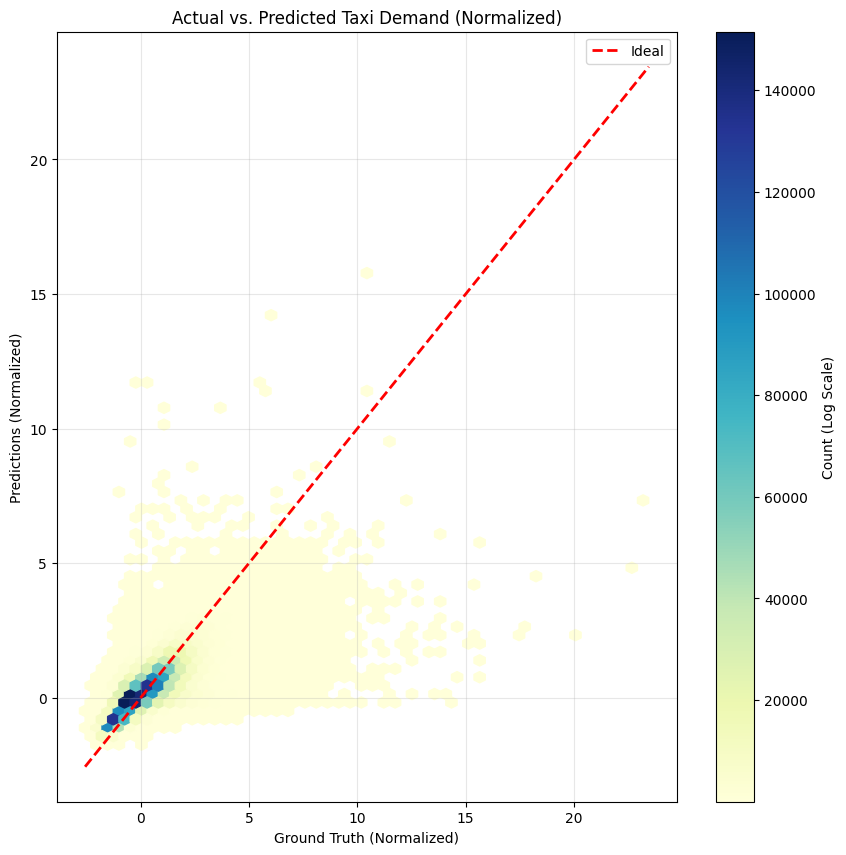

In [12]:
def plot_results(labels, preds, logger, iters=0):
    plt.figure(figsize=(10, 10))
    
    # 1. Use Hexbin for large datasets to see density clearly
    # If the dataset is smaller, plt.scatter is fine, but hexbin handles overlap better
    hb = plt.hexbin(labels, preds, gridsize=50, cmap='YlGnBu', mincnt=1)
    cb = plt.colorbar(hb, label='Count (Log Scale)')
    
    # 2. Reference Line (The "Perfect Prediction" line)
    # Since your data is normalized, limits are usually between -3 and 10
    limits = [min(min(labels), min(preds)), max(max(labels), max(preds))]
    plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Ideal')
    
    plt.title('Actual vs. Predicted Taxi Demand (Normalized)')
    plt.xlabel('Ground Truth (Normalized)')
    plt.ylabel('Predictions (Normalized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Report to ClearML
    # This uploads the plot to the 'Results' tab in your task
    logger.report_matplotlib_figure(
        title="Prediction Analysis", 
        series="Truth vs Prediction Scatter", 
        figure=plt,
        iteration=iters
    )
    
    # Optional: Still show it locally if you are in a notebook
    plt.show()

# --- Execution ---
plot_results(labels_norm, preds_norm, logger)

/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



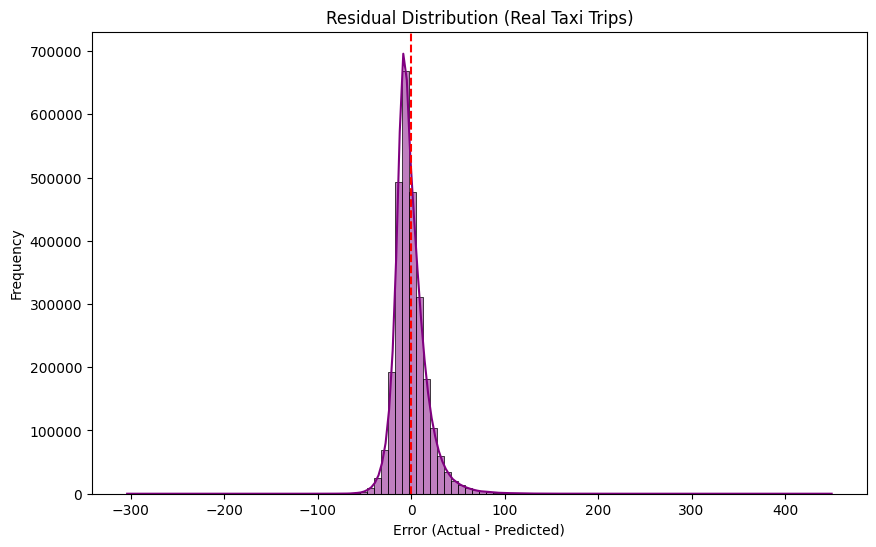

In [15]:

def plot_residuals(labels_norm, preds_norm, city_sigma, logger):
    # 1. Calculate the error in real taxi trips
    # (Actual - Predicted) * Sigma
    residuals_trips = (labels_norm - preds_norm) * city_sigma
    
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals_trips, bins=100, kde=True, color='purple')
    
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Residual Distribution (Real Taxi Trips)')
    plt.xlabel('Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    
    # 2. Log Mean Absolute Error (MAE)
    mae = np.mean(np.abs(residuals_trips))
    logger.report_scalar("Metrics", "MAE_Trips", iteration=0, value=mae)
    
    # 3. Report to ClearML
    logger.report_matplotlib_figure(
        title="Error Analysis", 
        series="Residual Histogram", 
        figure=plt
    )
    plt.show()

# Replace with your actual city-wide or location-specific sigma
CITY_SIGMA = 25.4 
plot_residuals(labels_norm, preds_norm, CITY_SIGMA, logger)

Vemos que el modelo sufre mucho cuando hay una franja muy demandada, el RMSE le cuesta mucho arriesgar a resultados muy grandes a la hora de entrenar, ya que al ser cuadrática, un fallo penaliza mucho. Usar otro loss como el hubber Loss, el cual mezcla un MAE y un RMSE será mejor probablemente

## Mejora del modelo:

En cara a que se llevasea producción no podemos hacer estas operaiones sin control, necesitamos un pipeline, que, por lo menos desde el dataframe agregado podamos crear el dataframe ideal para el modelo y entrenar al mismo, además de poder hacer predicciones no normalizadas.

Para ello haremos varias modifocaciones:

- Usaremos la salida de la LSTM seran los espacios ocultos que se crean, de esta manera, la capa densa podrá ponderar pesos para cada paso temporal y podrá decidir si alguna variable es mas importante cuanto más pasada sea, similar a la idea del TFT.
- Hemos visto que el modelo no sabe predecir bien los picos, lo que es un problema, esto es debido a la función de loss que pensaliza cuadráticamente, por tanto usaremos el Hubber loss.
- Por último, con el fin de crear un pipeline automático de spark, usaremos azure synapse para llevar el modelo de torch a spark.
- En vez de escaalr por todo el pasado, usaremos solo la propia ventana, lo que es conocido como rolling window scaling
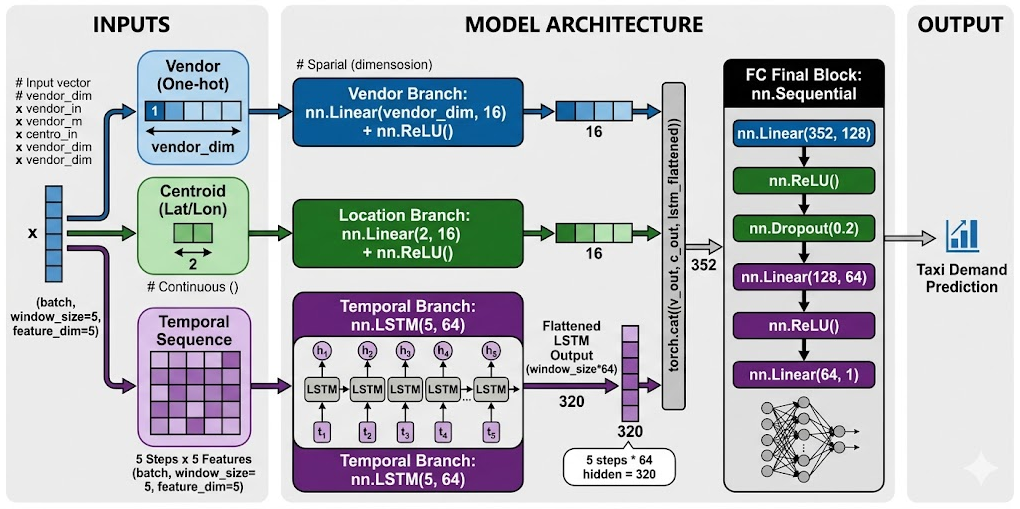


Reiniciemos todo:

In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient


from pyspark.ml.feature import StringIndexer, OneHotEncoder,VectorAssembler, StandardScaler, SQLTransformer, Imputer
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.sql.window import Window
import math
from torch.utils.data import IterableDataset, DataLoader
import s3fs
import pyarrow.parquet as pq

from clearml import Task
from tqdm.auto import tqdm

from setup import setenv
setenv()


In [10]:
spark = MinioSparkClient(
    endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
    access_key=os.getenv("MINIO_ACCESS_KEY"),
    secret_key=os.getenv("MINIO_SECRET_KEY"),
    bucket_name="pd2",
    base_dir="cityenjoyer",
    memory = 16,
    heapsize = 8,
    num_part = 2000,
    verbose=True
)
spark.connect()

In [11]:
if "df_transformed" in locals():
    df = df_transformed
else:
    df = spark.read_parquet("prepared_for_model/20260318_143014_agg.parquet")

df.show()

+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|avg_amount| Latitude| Longitude|hour|dow|            hour_sin|            hour_cos|            dow_sin|            dow_cos|
+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|       0|         262|2023-06-01 00:00:00|     4|      4377.0|    1447.5|40.775932| -73.94651|   0|  5|                 0.0|                 1.0|-0.9749279121818236|-0.2225209339563146|
|       0|         113|2023-06-01 05:00:00|     4|    17786.75|   4915.75| 40.73258| -73.99431|   5|  5|  0.9659258262890682| 0.25881904510252096|-0.9749279121818236|-0.2225209339563146|
|       0|         239|2023-06-01 06:00:00|    63|     8703.19| 3

In [3]:

class ExTLSTM(nn.Module):
    def __init__(self, vendor_dim, window_size=5, feature_dim=3):
        super(ExTLSTM, self).__init__()
        self.vendor_dim = vendor_dim
        self.window_size = window_size
        self.feature_dim = feature_dim
        
        self.vendor_fc = nn.Linear(vendor_dim, 16)
        self.centroid_fc = nn.Linear(2, 16)
        self.time_fc = nn.Linear(4, 16)
        
        self.lstm = nn.LSTM(input_size=feature_dim, hidden_size=64, 
                            num_layers=1, batch_first=True)
        
        # Entrada final: 16 (vendor) + 16 (lat/lon) + 16 (day/week)  + (64 hidden states)
        combined_dim = 16 + 16 + 16 + 64
        
        self.fc_final = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        idx_v = self.vendor_dim
        idx_c = idx_v + 2
        idx_t = idx_c + 4
        
        vendor_data = x[:, :idx_v]
        centroid_data = x[:, idx_v : idx_c]
        time_data = x[:, idx_c : idx_t]
        
        temporal_data = x[:, idx_t:].view(-1, self.window_size, self.feature_dim)
        
        v_out = torch.relu(self.vendor_fc(vendor_data))
        c_out = torch.relu(self.centroid_fc(centroid_data))
        t_out = torch.relu(self.time_fc(time_data))

        out, _ = self.lstm(temporal_data)

        lstm_out = torch.mean(out, dim=1)
        
        # Concatenamos todo
        combined = torch.cat((v_out, c_out, t_out, lstm_out), dim=1)
        return self.fc_final(combined)

In [4]:
#La siguiente expession es el equivalente al rolling window 
def get_pipeline(label):
    '''
    Crea y devuelve un pipeline para una variable objetivo label
    '''
    sql_logic = f"""
    SELECT *,
        -- Lags de DEMANDA, DISTANCIA y MONTO
        COALESCE(LAG(demand_sc, 5) OVER (p), 0.0) as d_t5, COALESCE(LAG(demand_sc, 4) OVER (p), 0.0) as d_t4, 
        COALESCE(LAG(demand_sc, 3) OVER (p), 0.0) as d_t3, COALESCE(LAG(demand_sc, 2) OVER (p), 0.0) as d_t2, COALESCE(LAG(demand_sc, 1) OVER (p), 0.0) as d_t1,
     
        COALESCE(LAG(avg_distance_sc, 5) OVER (p), 0.0) as dist_t5, COALESCE(LAG(avg_distance_sc, 4) OVER (p), 0.0) as dist_t4, 
        COALESCE(LAG(avg_distance_sc, 3) OVER (p), 0.0) as dist_t3, COALESCE(LAG(avg_distance_sc, 2) OVER (p), 0.0) as dist_t2, COALESCE(LAG(avg_distance_sc, 1) OVER (p), 0.0) as dist_t1,

        COALESCE(LAG(avg_amount_sc, 5) OVER (p), 0.0) as amt_t5, COALESCE(LAG(avg_amount_sc, 4) OVER (p), 0.0) as amt_t4, 
        COALESCE(LAG(avg_amount_sc, 3) OVER (p), 0.0) as amt_t3, COALESCE(LAG(avg_amount_sc, 2) OVER (p), 0.0) as amt_t2, COALESCE(LAG(avg_amount_sc, 1) OVER (p), 0.0) as amt_t1
    FROM (
        SELECT *,
            COALESCE(AVG({label}) OVER (w), 0) as mean,
            COALESCE(STDDEV({label}) OVER (w), 1) as std,

            COALESCE((demand - AVG(demand) OVER (w)) / COALESCE(NULLIF(STDDEV(demand) OVER (w), 0.0), 1.0), 0.0) as demand_sc,
            COALESCE((avg_distance - AVG(avg_distance) OVER (w)) / COALESCE(NULLIF(STDDEV(avg_distance) OVER (w), 0.0), 1.0), 0.0) as avg_distance_sc,
            COALESCE((avg_amount - AVG(avg_amount) OVER (w)) / COALESCE(NULLIF(STDDEV(avg_amount) OVER (w), 0.0), 1.0), 0.0) as avg_amount_sc
        FROM __THIS__
        WINDOW w AS (PARTITION BY VendorID, PULocationID ORDER BY timestamp ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING)
    ) AS Escalamiento
    WINDOW p AS (PARTITION BY VendorID, PULocationID ORDER BY timestamp)
    """
    window_transformer = SQLTransformer(statement=sql_logic)

    # Hacemos el one-hot
    indexer = StringIndexer(inputCol="VendorID", outputCol="VendorIndex", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol="VendorIndex", outputCol="VendorVector")


    # Escalamos las coordenadas
    coord_assembler = VectorAssembler(inputCols=["Latitude", "Longitude"], outputCol="coords_vec")
    coord_scaler = StandardScaler(inputCol="coords_vec", outputCol="coords_scaled", withMean=True, withStd=True)

    # Ensamblado del Vector Final
    # El orden aquí debe coincidir con el despiece del modelo en PyTorch: [Vendor, Centroide, Secuencia]
    temporal_features = []
    for i in range(5, 0, -1): 
        temporal_features += [
            f"d_t{i}", f"dist_t{i}", f"amt_t{i}", 
        ]

    current_time_features = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]

    assembler = VectorAssembler(
        inputCols=["VendorVector", "coords_scaled"] + current_time_features +temporal_features,
        outputCol="features"
    )
    
    logic_denorm = """
    SELECT *,
        (prediction * std) + mean as prediction_real
    FROM __THIS__
    """

    denormalizer = SQLTransformer(statement=logic_denorm)
    # Pipeline completo
    return  Pipeline(stages=[window_transformer, indexer, encoder, coord_assembler, coord_scaler, assembler])
    



In [12]:
pipeline = get_pipeline("demand")
pipeline_fit =pipeline.fit(df)
res = pipeline_fit.transform(df)


El pipeline anterior aunestá incompleto, queda la desnormalizacion y el propio modelo, para crear el modelo primero debemos entrenarlo en local, para aprovechar todos nuestros recursos

In [7]:

pipeline = get_pipeline(label="demand")

#Ajustar y transformar
pipeline_model = pipeline.fit(df)
processed_df = pipeline_model.transform(df).filter("d_t5 IS NOT NULL")

# Seleccionar solo lo necesario para el entrenamiento
# Necesitamos 'features' (X) y el target (y)
data_to_train = processed_df.select("timestamp","features", "demand_sc")

In [8]:
data_to_train.show()

+-------------------+--------------------+---------+
|          timestamp|            features|demand_sc|
+-------------------+--------------------+---------+
|2021-01-09 12:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-11 09:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-12 08:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-13 08:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-14 08:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-15 08:00:00|(25,[2,4,5,6,7,8,...|      0.0|
|2021-01-16 10:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-17 12:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-19 11:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-20 19:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-21 06:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-25 06:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-26 06:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-27 06:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-28 06:00:00|[0.0,0.0,1.0,0.0,...|      0.0|
|2021-01-29 06:00:00|[0.0,0.0,1.0,0.0,...|    

In [9]:
data_to_train.count()


27558445

In [10]:
data_to_train.sort("timestamp").write.format("parquet") \
    .option("compression", "snappy").mode("overwrite") \
    .save("../data/lstm_model.parquet")

In [5]:
class TrainDataset(IterableDataset):
    def __init__(self, folder_path, split="train", train_ratio=0.8):
        self.folder_path = folder_path
        # Filtramos solo archivos .parquet reales
        all_files = sorted([
            os.path.join(folder_path, f) 
            for f in os.listdir(folder_path) 
            if f.endswith('.parquet') and not f.startswith('.')
        ])
        
        split_idx = int(len(all_files) * train_ratio)
        self.files = all_files[:split_idx] if split == "train" else all_files[split_idx:]
        print(f"[{split.upper()}] Dataset asignado con {len(self.files)} archivos.")

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        
        if worker_info is None:
            iter_files = self.files
        else:
            # REPARTO CRÍTICO PARA EVITAR DUPLICADOS
            per_worker = int(np.ceil(len(self.files) / float(worker_info.num_workers)))
            worker_id = worker_info.id
            iter_files = self.files[worker_id * per_worker : (worker_id + 1) * per_worker]

        for file in iter_files:
            try:
                table = pq.read_table(file)
                pdf = table.to_pandas()
                pdf = pdf.dropna(subset=["features", "demand_sc"])
                
                # Función to_dense interna
                def to_dense(x):
                    if x is None or not isinstance(x, dict): return None
                    try:
                        if x.get('type') == 1: return np.array(x['values'])
                        elif x.get('type') == 0:
                            res = np.zeros(int(x['size']))
                            res[np.array(x['indices'], dtype=int)] = x['values']
                            return res
                    except: return None
                    return None

                features_raw = [to_dense(f) for f in pdf["features"].values]
                valid_indices = [i for i, f in enumerate(features_raw) if f is not None]
                
                if not valid_indices: continue
                    
                X = np.stack([features_raw[i] for i in valid_indices]).astype(np.float32)
                y = pdf["demand_sc"].values[valid_indices].astype(np.float32).reshape(-1, 1)

                for i in range(len(X)):
                    yield torch.from_numpy(X[i]), torch.from_numpy(y[i])
            except Exception as e:
                pass

In [6]:
train_loader = DataLoader(TrainDataset("../data/lstm_model.parquet", split="train"), batch_size=1024, num_workers=4,
    prefetch_factor=2 )
val_loader = DataLoader(TrainDataset("../data/lstm_model.parquet", split="val"), batch_size=1024,num_workers = 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ExTLSTM(4,5,3)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.HuberLoss(delta = 0.2)

epochs = 30
best_val_loss = float('inf')

[TRAIN] Dataset asignado con 26 archivos.
[VAL] Dataset asignado con 7 archivos.


In [ ]:
Task.set_offline(offline_mode=True)
task = Task.init(
    project_name='Taxi Demand Prediction', 
    task_name='ExT-LSTM Training',
    reuse_last_task_id=True # Permite continuar si se corta el notebook
)
logger = task.get_logger()

epochs = 30
for epoch in range(epochs):
    # FASE TRAIN
    model.train()
    train_running_loss = 0.0
    counter_t = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")
    
    for bx, by in pbar:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        outputs = model(bx)
        loss = criterion(outputs, by)
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
        counter_t += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    # FASE VALIDACIÓN
    model.eval()
    val_running_loss = 0.0
    counter_v = 0
    with torch.no_grad():
        for vx, vy in val_loader:
            vx, vy = vx.to(device), vy.to(device)
            v_loss = criterion(model(vx), vy)
            val_running_loss += v_loss.item()
            counter_v += 1

    # PROMEDIOS Y LOGGING
    avg_train_loss = train_running_loss / counter_t
    avg_val_loss = val_running_loss / counter_v

    # REPORTE A CLEARML
    logger.report_scalar(title='Loss', series='Train', iteration=epoch, value=avg_train_loss)
    logger.report_scalar(title='Loss', series='Val', iteration=epoch, value=avg_val_loss)

    print(f"Epoch {epoch+1} Finalizada - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # GUARDAR CHECKPOINT
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        #task.update_output_model(model_path="best_model.pth", name="Best LSTM Model")

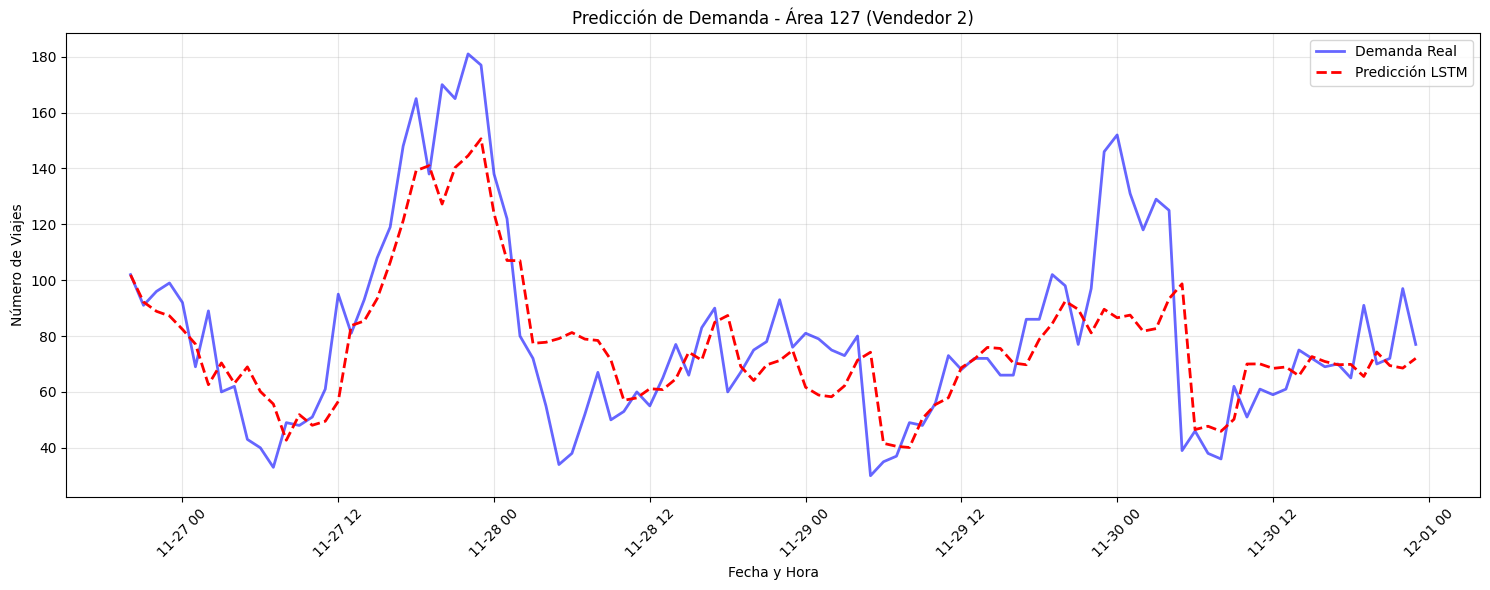

In [13]:

def plot_demand_forecast(res_spark_df, model, location_id=127, vendor_id=2, last_n=100):
    """
    Filtra, predice y grafica la demanda real vs predicha.
    """
    # 1. Filtramos en Spark y traemos solo lo necesario
    # Ordenamos por timestamp descendente para tomar las "últimas" N horas
    pd_subset = res_spark_df.filter(
        (res_spark_df.PULocationID == location_id) & 
        (res_spark_df.VendorID == vendor_id)
    ).sort("timestamp", ascending=False).limit(last_n).toPandas()

    # Volvemos a ordenar cronológicamente para el gráfico
    pd_subset = pd_subset.sort_values("timestamp")

    if pd_subset.empty:
        print("No se encontraron datos para los filtros especificados.")
        return

    # 2. Preparar los tensores para el modelo
    # Usamos la lógica de conversión que definimos para el dataset
    def row_to_tensor(row):
        feat = row['features']
        if isinstance(feat, dict): # Si viene como SparseVector de Spark
            res = np.zeros(feat['size'])
            res[feat['indices']] = feat['values']
            return res
        return np.array(feat) # Si viene como DenseVector

    X_list = [row_to_tensor(r) for _, r in pd_subset.iterrows()]
    X_tensor = torch.from_numpy(np.stack(X_list)).float().to(device)

    # 3. Inferencia
    model.eval()
    with torch.no_grad():
        preds_sc = model(X_tensor).cpu().numpy().flatten()

    # 4. DENORMALIZACIÓN (Paso crítico)
    # Real = (Pred_normalizado * std) + mean
    means = pd_subset['mean'].values
    stds = pd_subset['std'].values
    real_demand = pd_subset['demand'].values
    
    # Aplicamos la fórmula inversa
    predicted_demand = (preds_sc * stds) + means
    
    # Aseguramos que no haya predicciones negativas (físicamente imposibles)
    predicted_demand = np.maximum(predicted_demand, 0)

    # 5. Plotting
    plt.figure(figsize=(15, 6))
    plt.plot(pd_subset['timestamp'], real_demand, label='Demanda Real', color='blue', alpha=0.6, linewidth=2)
    plt.plot(pd_subset['timestamp'], predicted_demand, label='Predicción LSTM', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Predicción de Demanda - Área {location_id} (Vendedor {vendor_id})')
    plt.xlabel('Fecha y Hora')
    plt.ylabel('Número de Viajes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Uso:
plot_demand_forecast(res, model, location_id=127, vendor_id=2, last_n=100)

In [17]:

def calculate_full_mae(res_spark_df, model, sample_n=1000000):
    """
    Calcula el MAE real sobre una muestra representativa de N filas
    usando el modelo cargado en memoria.
    """
    print(f"Extrayendo {sample_n} registros de Spark...")
    # Tomamos una muestra aleatoria para que el MAE sea estadísticamente válido
    # 1.000.000 / 27.000.000 approx 0.037
    fraction = min(sample_n / 27000000, 1.0)
    pdf = res_spark_df.sample(False, fraction).toPandas()
    
    if pdf.empty:
        print("Error: No se pudieron extraer datos.")
        return

    # 2. Preparar los datos (Misma lógica que el plot)
    def to_dense_array(feat):
        if isinstance(feat, dict): # SparseVector de Spark
            res = np.zeros(feat['size'])
            res[feat['indices']] = feat['values']
            return res
        return np.array(feat)

    print("Preparando tensores...")
    X_raw = np.stack([to_dense_array(f) for f in pdf["features"].values]).astype(np.float32)
    X_tensor = torch.from_numpy(X_raw).to(device)
    
    # 3. Inferencia por mini-batches (para no saturar la GPU)
    model.eval()
    all_preds = []
    batch_size = 5000 
    
    print("Calculando predicciones...")
    with torch.no_grad():
        for i in tqdm(range(0, len(X_tensor), batch_size)):
            batch_x = X_tensor[i : i + batch_size]
            preds = model(batch_x).cpu().numpy().flatten()
            all_preds.extend(preds)
    
    pdf["prediction_sc"] = all_preds

    # 4. DESNORMALIZACIÓN Y MAE
    # Formula: Real = (Pred_sc * std) + mean
    pdf["pred_real"] = (pdf["prediction_sc"] * pdf["std"]) + pdf["mean"]
    # Forzamos a que no haya demanda negativa
    pdf["pred_real"] = np.maximum(pdf["pred_real"], 0)
    
    # Calculamos error absoluto
    pdf["abs_error"] = np.abs(pdf["pred_real"] - pdf["demand"])
    
    mae_final = pdf["abs_error"].mean()
    std_error = pdf["abs_error"].std()

    print("\n" + "="*30)
    print(f" RESULTADOS MAE (VIAJES REALES)")
    print(f" Muestra: {len(pdf)} registros")
    print(f" MAE: {mae_final:.4f} viajes")
    print(f" Std Dev Error: {std_error:.4f}")
    print("="*30)
    
    return mae_final

# Ejecución:
calculate_full_mae(res, model, sample_n=1000000)

Extrayendo 1000000 registros de Spark...


Preparando tensores...
Calculando predicciones...


  0%|          | 0/205 [00:00<?, ?it/s]


 RESULTADOS MAE (VIAJES REALES)
 Muestra: 1021832 registros
 MAE: 7.7369 viajes
 Std Dev Error: 12.8868


np.float64(7.736871385082391)